## julia

In [2]:
x = 1:10
sum(x)

55

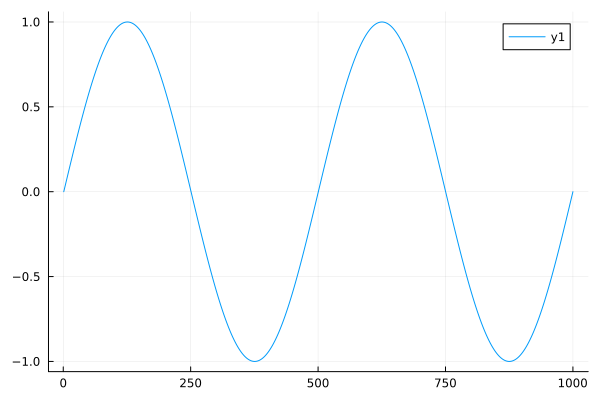

In [7]:
using Plots
plot(1:1000, sin.(range(0, 4π, length=1000)))

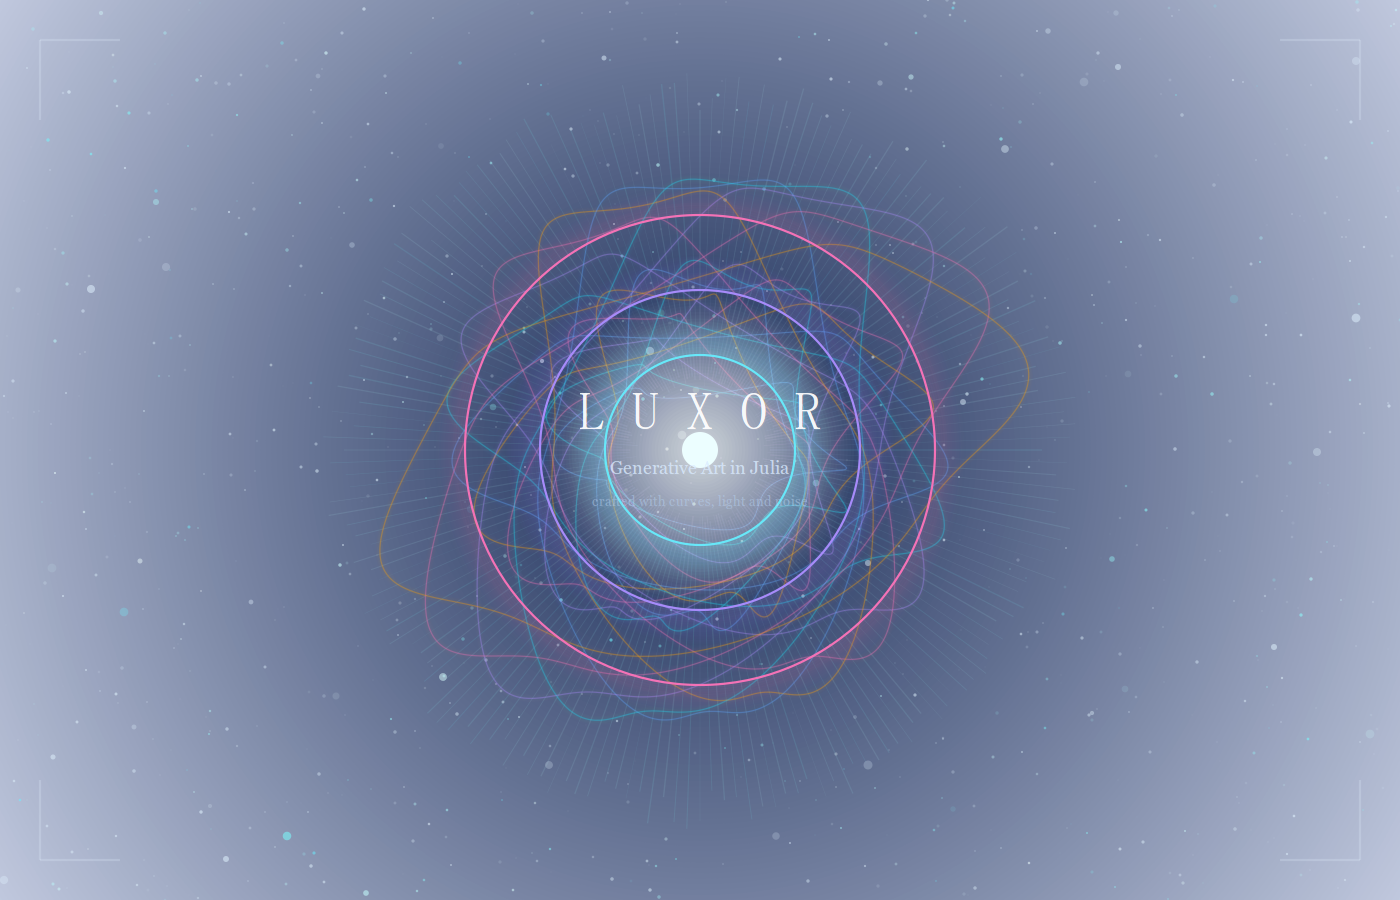

In [16]:
using Luxor
using Colors
using Random

Random.seed!(42)

# 画布尺寸
W = 1400
H = 900

# 一些辅助函数
lerp(a, b, t) = a + (b - a) * t

function blend(c1::Colorant, c2::Colorant, t)
    RGB(
        lerp(red(c1),   red(c2),   t),
        lerp(green(c1), green(c2), t),
        lerp(blue(c1),  blue(c2),  t),
    )
end

# 径向“伪渐变”背景：用很多同心圆模拟
function radial_background(c_inner, c_outer; steps=180)
    maxr = hypot(W, H) / 1.4
    for i in reverse(1:steps)
        t = (i - 1) / (steps - 1)
        setcolor(blend(c_inner, c_outer, t))
        circle(O, maxr * t, :fill)
    end
end

# 发光圆环
function glowing_ring(r; basecolor=colorant"#6EE7F9", n=22, alpha0=0.12, lw=2.5)
    for i in 1:n
        setline(lw + i * 1.5)
        setcolor(RGBA(red(basecolor), green(basecolor), blue(basecolor), alpha0 / (i^0.75)))
        circle(O, r + i * 1.6, :stroke)
    end
    setline(2.2)
    setcolor(basecolor)
    circle(O, r, :stroke)
end

# 曲线花瓣/轨道
function flowing_orbits(n_orbits=18)
    palette = [
        colorant"#60A5FA",
        colorant"#22D3EE",
        colorant"#A78BFA",
        colorant"#F472B6",
        colorant"#F59E0B",
    ]

    for k in 1:n_orbits
        hue = palette[mod1(k, length(palette))]
        a = 120 + 10k
        b = 60 + 6k
        rot = 2π * (k - 1) / n_orbits

        pts = Point[]
        for t in range(0, 2π; length=500)
            # 在椭圆基础上叠一点波纹
            x = a * cos(t) + 18 * sin(5t + 0.7k)
            y = b * sin(t) + 14 * cos(4t + 0.3k)
            p = Point(x, y)
            p = rotatepoint(p, O, rot)
            push!(pts, p)
        end

        for glow in 1:6
            setline(1.2 + glow * 1.3)
            setcolor(RGBA(red(hue), green(hue), blue(hue), 0.03 / glow))
            poly(pts, :stroke, close=false)
        end

        setline(1.2)
        setcolor(RGBA(red(hue), green(hue), blue(hue), 0.35))
        poly(pts, :stroke, close=false)
    end
end

# 放射细线
function radial_lines(n=160, r1=80, r2=330)
    for i in 1:n
        θ = 2π * (i - 1) / n
        p1 = polar(r1 + rand(-8.0:0.5:8.0), θ)
        p2 = polar(r2 + rand(-20.0:1.0:20.0), θ)

        setline(rand() * 1.2 + 0.2)
        c = blend(colorant"#67E8F9", colorant"#C084FC", rand())
        setcolor(RGBA(red(c), green(c), blue(c), 0.10))
        line(p1, p2, :stroke)
    end
end

# 粒子
function particles(n=1200)
    for _ in 1:n
        x = rand(-W/2:W/2)
        y = rand(-H/2:H/2)
        r = rand() < 0.92 ? rand() * 1.6 + 0.2 : rand() * 3.5 + 1.0

        c = rand() < 0.6 ? colorant"#E0F2FE" : blend(colorant"#67E8F9", colorant"#F9A8D4", rand())
        setcolor(RGBA(red(c), green(c), blue(c), rand() * 0.5 + 0.08))
        circle(Point(x, y), r, :fill)
    end
end

# 中央核心
function central_core()
    # 核心柔光
    for i in reverse(1:45)
        t = i / 45
        c = blend(colorant"#FFFFFF", colorant"#7DD3FC", 0.6)
        setcolor(RGBA(red(c), green(c), blue(c), 0.02 + 0.025 * (1 - t)))
        circle(O, 10 + i * 3.2, :fill)
    end

    setcolor(colorant"#ECFEFF")
    circle(O, 18, :fill)

    glowing_ring(95,  basecolor=colorant"#67E8F9", n=16, alpha0=0.11, lw=1.8)
    glowing_ring(160, basecolor=colorant"#A78BFA", n=14, alpha0=0.09, lw=1.6)
    glowing_ring(235, basecolor=colorant"#F472B6", n=12, alpha0=0.07, lw=1.4)
end

# 角落装饰
function corner_frame()
    setline(2.2)
    setcolor(RGBA(0.9, 0.95, 1.0, 0.22))

    margin = 40
    len = 80

    # 左上
    line(Point(-W/2 + margin, -H/2 + margin), Point(-W/2 + margin + len, -H/2 + margin), :stroke)
    line(Point(-W/2 + margin, -H/2 + margin), Point(-W/2 + margin, -H/2 + margin + len), :stroke)

    # 右上
    line(Point(W/2 - margin, -H/2 + margin), Point(W/2 - margin - len, -H/2 + margin), :stroke)
    line(Point(W/2 - margin, -H/2 + margin), Point(W/2 - margin, -H/2 + margin + len), :stroke)

    # 左下
    line(Point(-W/2 + margin, H/2 - margin), Point(-W/2 + margin + len, H/2 - margin), :stroke)
    line(Point(-W/2 + margin, H/2 - margin), Point(-W/2 + margin, H/2 - margin - len), :stroke)

    # 右下
    line(Point(W/2 - margin, H/2 - margin), Point(W/2 - margin - len, H/2 - margin), :stroke)
    line(Point(W/2 - margin, H/2 - margin), Point(W/2 - margin, H/2 - margin - len), :stroke)
end

# 标题
function add_text()
    setcolor(RGBA(1, 1, 1, 0.92))
    fontsize(54)
    fontface("Georgia-Bold")
    Luxor.text("L U X O R", Point(0, -20), halign=:center)

    setcolor(RGBA(0.85, 0.92, 1.0, 0.75))
    fontsize(18)
    fontface("Georgia")
    Luxor.text("Generative Art in Julia", Point(0, 24), halign=:center)

    setcolor(RGBA(0.72, 0.82, 0.95, 0.45))
    fontsize(13)
    Luxor.text("crafted with curves, light and noise", Point(0, 56), halign=:center)
end

@png begin
    origin()
    background(colorant"#070B17")

    radial_background(colorant"#182A55", colorant"#070B17", steps=220)
    particles(1000)
    radial_lines(180, 70, 360)
    flowing_orbits(20)
    central_core()
    corner_frame()
    add_text()
end W H "luxor_poster.png"